# MSCP: Multi-Scale Contrast Preserving Encoder-Decoder for Local Change Detection in Thermal Video

**Faithful PyTorch reimplementation** of:
> Panda et al., *"A Multi-Scale Contrast Preserving Encoder-Decoder Architecture for Local Change Detection From Thermal Video Scenes"*, IEEE TIFS, Vol. 19, 2024.

**Pipeline:** Encoder (4 blocks x 5 modules, conv + atrous, residual skips)
`->` **MSCP block** (multi-scale contrast preservation, the core novelty)
`->` Decoder (3 blocks + 2 fusion layers + sigmoid).

**Target:** CDnet 2014 *thermal* category (5 scenes) via the Kaggle mirror `maamri95/cdnet2014`.
Trained on **N = 200 frames** (as in the paper). Metrics: **Precision / Recall / F-measure / PWC**.

> Note: no official code was released by the authors. Where the paper's text is internally
> ambiguous (e.g. stated feature widths 192/240 vs. filter counts, exact fusion arithmetic),
> a short comment cites the paper section. See the "Assumptions" markdown at the end.

## 1. Environment & GPU check

In [1]:
# Colab: install deps (skip if present). We do NOT `import kaggle` because the
# kaggle package authenticates (and crashes) on import in notebooks. We only need
# the `kaggle` CLI binary, which is used via subprocess in the download cell.
import sys, subprocess, shutil
def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
for mod, pkg in [("torch","torch"),("torchvision","torchvision"),
                 ("cv2","opencv-python-headless"),("matplotlib","matplotlib"),
                 ("pandas","pandas"),("nbformat","nbformat")]:
    try:
        __import__(mod)
    except ImportError:
        pip(pkg)
# ensure the kaggle CLI is installed WITHOUT importing the package
if not shutil.which("kaggle"):
    pip("kaggle")
import torch, torchvision, cv2
import numpy as np, matplotlib.pyplot as plt, glob, os, random, math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

torch 2.11.0+cu128 | device: cuda


## 2. Kaggle authentication

In [ ]:
# --- Kaggle authentication ---
# Works on Colab WEB, VS Code (Colab runtime), or local. Fill in ONE option.
import os, json
KAGGLE_DIR = os.path.expanduser("~/.kaggle")
os.makedirs(KAGGLE_DIR, exist_ok=True)

# >>> OPTION 1 (simplest, works everywhere incl. VS Code): paste your values <<<
KAGGLE_API_TOKEN = ""    # e.g. "KGAT_xxxxxxxx"   (new token)
KAGGLE_USERNAME  = ""    # legacy kaggle.json username
KAGGLE_KEY       = ""    # legacy kaggle.json key

# OPTION 2: Colab WEB Secrets (the key icon) -- skipped automatically in VS Code
try:
    from google.colab import userdata
    KAGGLE_API_TOKEN = KAGGLE_API_TOKEN or userdata.get("KAGGLE_API_TOKEN")
    KAGGLE_USERNAME  = KAGGLE_USERNAME  or userdata.get("KAGGLE_USERNAME")
    KAGGLE_KEY       = KAGGLE_KEY       or userdata.get("KAGGLE_KEY")
except Exception:
    pass

# OPTION 3: environment variables / files already on disk
KAGGLE_API_TOKEN = KAGGLE_API_TOKEN or os.environ.get("KAGGLE_API_TOKEN")
KAGGLE_USERNAME  = KAGGLE_USERNAME  or os.environ.get("KAGGLE_USERNAME")
KAGGLE_KEY       = KAGGLE_KEY       or os.environ.get("KAGGLE_KEY")
at_path = os.path.join(KAGGLE_DIR, "access_token")
kj_path = os.path.join(KAGGLE_DIR, "kaggle.json")
if not KAGGLE_API_TOKEN and os.path.exists(at_path):
    KAGGLE_API_TOKEN = open(at_path).read().strip()
if not (KAGGLE_USERNAME and KAGGLE_KEY) and os.path.exists(kj_path):
    d = json.load(open(kj_path)); KAGGLE_USERNAME = d.get("username"); KAGGLE_KEY = d.get("key")

assert KAGGLE_API_TOKEN or (KAGGLE_USERNAME and KAGGLE_KEY), (
    "\n*** No Kaggle credentials found. Fill in OPTION 1 above (paste your token / username+key).")

# Write whichever credential we have so the `kaggle` CLI can use it
if KAGGLE_API_TOKEN:
    open(at_path, "w").write(KAGGLE_API_TOKEN); os.chmod(at_path, 0o600)
    print("Wrote access token ->", at_path)
if KAGGLE_USERNAME and KAGGLE_KEY:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, open(kj_path, "w"))
    os.chmod(kj_path, 0o600)
    print("Wrote kaggle.json ->", kj_path)

Wrote kaggle.json -> /root/.kaggle/kaggle.json


## 3. Download CDnet 2014 + verify the thermal subset

In [3]:
DATA_ROOT = "./data"
if not os.path.isdir(os.path.join(DATA_ROOT, "dataset")):
    os.makedirs(DATA_ROOT, exist_ok=True)
    print("Downloading CDnet 2014 from Kaggle (large; may take a few minutes)...")
    r = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "maamri95/cdnet2014",
         "-p", DATA_ROOT, "--unzip"],
        capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print("STDERR:", r.stderr[-2000:])
        raise RuntimeError("Kaggle download failed. Check credentials in the previous cell.")
    print("Download complete.")
else:
    print("Dataset already present, skipping download.")

THERMAL = os.path.join(DATA_ROOT, "dataset", "thermal")
assert os.path.isdir(THERMAL), (
    "Thermal category missing in this Kaggle copy. Inspect ./data/dataset; "
    "fall back to another CDnet2014 mirror if needed.")
SCENES = sorted([d for d in os.listdir(THERMAL) if os.path.isdir(os.path.join(THERMAL, d))])
print("Thermal scenes:", SCENES)

s0 = os.path.join(THERMAL, SCENES[0])
roi = cv2.imread(os.path.join(s0, "ROI.bmp"), cv2.IMREAD_UNCHANGED)
gts = sorted(glob.glob(os.path.join(s0, "groundtruth", "*.png")))
gt0 = cv2.imread(gts[0], cv2.IMREAD_UNCHANGED)
print("ROI unique:", np.unique(roi)[:8], "| GT unique:", np.unique(gt0)[:8])
print("GT frames in %s:" % SCENES[0], len(gts))

Download complete.
Thermal scenes: ['corridor', 'diningRoom', 'lakeSide', 'library', 'park']
ROI unique: [255] | GT unique: [85]
GT frames in corridor: 5400


## 4. Configuration (all hyperparameters from Sec. IV-A)

In [4]:
CONFIG = dict(
    in_channels   = 3,        # thermal frames loaded as RGB (replicated grayscale)
    img_size      = (240, 320),  # H,W divisible by 16 so H/4 is exact
    n_train       = 200,      # N = 200 training frames (paper)
    val_frac      = 0.10,     # 10% validation split (paper: 90/10)
    batch_size    = 1,        # paper uses batch=1 (acts as regularization)
    lr            = 1e-4,     # initial learning rate
    rmsprop_rho   = 0.9,      # RMSProp moving-average decay
    rmsprop_eps   = 1e-8,
    lr_decay_factor = 0.1,    # lr x0.1 if val loss stalls 5 epochs
    lr_decay_patience = 5,
    max_epochs    = 100,
    early_stop_patience = 10,
    threshold     = 0.9,      # pixel decision threshold (paper, Sec. III-C)
    sd_rate       = 0.25,     # spatial-dropout rate
    seed          = SEED,
)

## 5. Dataset class (frame<->GT pairing, ROI mask, class weights)

In [5]:
class CDDnetThermal(torch.utils.data.Dataset):
    """Loads CDnet2014 thermal scenes. CDnet GT encoding:
       0   -> background, 85 -> shadow (treat as background),
       170 -> unknown / out of ROI (IGNORE), 255 -> foreground."""
    def __init__(self, scene_dirs, size, n=None, val_frac=0.1, split="train", seed=42):
        self.size = size  # (H,W)
        rng = np.random.RandomState(seed)
        pairs = []  # (frame, gt, roi)
        for sd in scene_dirs:
            # input folder: 'input' (official) or 'in'
            in_dir = os.path.join(sd, "input")
            if not os.path.isdir(in_dir):
                cand = [c for c in glob.glob(os.path.join(sd, "*")) if os.path.isdir(c)
                        and os.path.basename(c).lower() in ("in",)]
                in_dir = cand[0] if cand else sd
            frames = sorted(glob.glob(os.path.join(in_dir, "*.jpg")) +
                            glob.glob(os.path.join(in_dir, "*.png")))
            for f in frames:
                idx = int("".join(ch for ch in os.path.basename(f).split(".")[0] if ch.isdigit()))
                gt = os.path.join(sd, "groundtruth", ("gt%06d.png" % idx))
                if os.path.exists(gt):
                    pairs.append((f, gt, os.path.join(sd, "ROI.bmp")))
        self.pairs = pairs
        # stratified shuffle + split
        idx = np.arange(len(pairs)); rng.shuffle(idx)
        self.pairs = [pairs[i] for i in idx]
        n_val = max(1, int(len(self.pairs) * val_frac))
        if split == "train":
            if n is not None and n < (len(self.pairs) - n_val):
                self.pairs = self.pairs[:n]          # take first n (already shuffled)
            else:
                self.pairs = self.pairs[:-n_val]
        else:
            self.pairs = self.pairs[-n_val:]
        print(f"[{split}] {len(self.pairs)} frames from {len(scene_dirs)} scenes")

    def __len__(self): return len(self.pairs)

    def _load(self, path, mode):
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img.ndim == 2 and mode == "color":
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.ndim == 3 and mode == "gray":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return img

    def __getitem__(self, i):
        fpath, gtpath, roipath = self.pairs[i]
        H, W = self.size
        frame = cv2.resize(self._load(fpath, "color"), (W, H))
        gt = cv2.resize(self._load(gtpath, "gray"), (W, H), interpolation=cv2.INTER_NEAREST)
        roi = cv2.resize(self._load(roipath, "gray"), (W, H), interpolation=cv2.INTER_NEAREST)
        # ---- decode GT ----
        fg = (gt >= 200).astype(np.float32)                 # 255 -> foreground
        bg = ((gt < 200) & (gt != 170)).astype(np.float32)  # 0 & 85(shadow) -> bg
        valid = ((roi >= 127) & (gt != 170)).astype(np.float32)  # ignore unknown / outside ROI
        label = fg.copy()                                    # 1 fg, 0 bg
        # ---- per-frame inverse-frequency class weight (Sec. IV-A) ----
        n_fg = max(1.0, float((valid * fg).sum()))
        n_bg = max(1.0, float((valid * (1 - fg)).sum()))
        w_fg = (n_fg + n_bg) / (2.0 * n_fg)   # higher weight for rare fg
        w_bg = (n_fg + n_bg) / (2.0 * n_bg)
        weight = np.where(label > 0.5, w_fg, w_bg).astype(np.float32)
        # ---- to tensors ----
        x = torch.from_numpy(frame.astype(np.float32) / 255.0).permute(2, 0, 1)  # C,H,W
        return (x,
                torch.from_numpy(label)[None],
                torch.from_numpy(valid)[None],
                torch.from_numpy(weight)[None])

## 6. Custom layers (ContrastNorm, SpatialDropout, atrous branch)

In [6]:
import torch.nn as nn, torch.nn.functional as F

class ContrastNorm(nn.Module):
    """Contrast Normalization (Eq. 3) == Instance Normalization (Ulyanov [79]).
    Per-sample, per-channel normalization over spatial dims. Preferred over BatchNorm
    for the small batch sizes used here (Sec. III-A)."""
    def __init__(self, ch, eps=1e-5):
        super().__init__()
        self.norm = nn.InstanceNorm2d(ch, eps=eps, affine=False)
    def forward(self, x): return self.norm(x)

class SpatialDropout(nn.Module):
    """Drops entire feature maps (whole channels) at rate p instead of single neurons
    (Sec. III-A-5). Equivalent to channel-wise dropout for spatially correlated maps."""
    def __init__(self, p=0.25):
        super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        return F.dropout2d(x, p=self.p, training=True)

## 7. Encoder (4 blocks x 5 modules) -> F [B,192,H/4,W/4]

In [7]:
class SparseModule(nn.Module):
    """Module 1 of a block: stacked 3x3 convs (sparse features) + 1x1 reduction to out_ch."""
    def __init__(self, in_ch, mid_ch, out_ch, n_conv):
        super().__init__()
        layers, prev = [], in_ch
        for _ in range(n_conv):
            layers += [nn.Conv2d(prev, mid_ch, 3, padding=1), ContrastNorm(mid_ch), nn.ReLU(inplace=True)]
            prev = mid_ch
        layers += [nn.Conv2d(prev, out_ch, 1)]                 # 1x1 reduction
        layers += [ContrastNorm(out_ch), nn.ReLU(inplace=True)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class AtrousModule(nn.Module):
    """Atrous (dilated) conv branch -> CN -> ReLU. Dilation extends receptive field
    without extra params/loss of resolution (Eq. 2)."""
    def __init__(self, in_ch, out_ch, rate):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=rate, dilation=rate)
        self.cn, self.act = ContrastNorm(out_ch), nn.ReLU(inplace=True)
    def forward(self, x): return self.act(self.cn(self.conv(x)))

class EncoderBlock(nn.Module):
    """5 modules (module1 sparse + atrous @2,4,8,16) summed element-wise (Sec. III-A)."""
    def __init__(self, in_ch, mid_ch, out_ch=64, n_sparse=2):
        super().__init__()
        self.m1 = SparseModule(in_ch, mid_ch, out_ch, n_sparse)
        self.a2  = AtrousModule(in_ch, out_ch, 2)
        self.a4  = AtrousModule(in_ch, out_ch, 4)
        self.a8  = AtrousModule(in_ch, out_ch, 8)
        self.a16 = AtrousModule(in_ch, out_ch, 16)
    def forward(self, x):
        return self.m1(x) + self.a2(x) + self.a4(x) + self.a8(x) + self.a16(x)

class Encoder(nn.Module):
    """4 residual blocks; outputs bottleneck F (192 ch @ H/4) and low-level features."""
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        self.b1 = EncoderBlock(in_ch, 64,  base, 2)
        self.b2 = EncoderBlock(base,  128, base, 2)
        self.b3 = EncoderBlock(base,  256, base, 3)
        self.b4 = EncoderBlock(base,  512, base, 3)
        self.sd, self.pool = SpatialDropout(0.25), nn.MaxPool2d(2, 2)
        self.proj1 = nn.Conv2d(base, base, 1)          # 1x1(64) on Block1 output
        self.fuse  = nn.Conv2d(base * 4, 192, 1)        # concat -> 192 (ASSUMPTION, see notes)
    def forward(self, x):
        o1 = self.b1(x); low_full = o1                  # keep full-res low-level for decoder
        z = self.pool(self.sd(o1)); o2 = self.b2(z) + z          # residual
        z = self.pool(self.sd(o2)); o3 = self.b3(z) + z
        z = self.sd(o3);            o4 = self.b4(z) + z          # no pool B3->B4
        o1p = self.proj1(o1)
        size = o4.shape[2:]
        o1a = F.interpolate(o1p, size=size, mode="bilinear", align_corners=False)
        o2a = F.interpolate(o2,  size=size, mode="bilinear", align_corners=False)
        Ff = self.fuse(torch.cat([o1a, o2a, o3, o4], dim=1))     # [B,192,H/4,W/4]
        return Ff, low_full

## 8. MSCP block (core novelty) -> Y [B,240,H/4,W/4]

In [8]:
class MSCPBlock(nn.Module):
    """Multi-Scale Contrast Preservation (Sec. III-B).
       Branch M: max-pool + 1x1 conv(64) + ReLU  -> pooled global cue
       Contrast branches X_j = ReLU( CV_j - AvgPool(CV_j) )  (Eq. 6)
         using a 3x3 conv and atrous convs @4,8,16.
       Concat M + X_j -> CN -> ReLU -> SpatialDropout."""
    def __init__(self, in_ch=192, out_ch=240, mid=64):
        super().__init__()
        self.M_conv = nn.Conv2d(in_ch, mid, 1)
        self.cv1 = nn.Conv2d(in_ch, mid, 3, padding=1)            # 3x3 branch
        self.cv2 = nn.Conv2d(in_ch, mid, 3, padding=4, dilation=4)
        self.cv3 = nn.Conv2d(in_ch, mid, 3, padding=8, dilation=8)
        self.cv4 = nn.Conv2d(in_ch, mid, 3, padding=16, dilation=16)
        self.avg = nn.AvgPool2d(3, stride=1, padding=1)           # keeps resolution
        self.proj = nn.Conv2d(mid * 5, out_ch, 1)                  # ->240 (ASSUMPTION)
        self.cn, self.act, self.sd = ContrastNorm(out_ch), nn.ReLU(inplace=True), SpatialDropout(0.25)
    def _contrast(self, conv, x):                                 # Eq. 6
        cv = conv(x)
        return F.relu(cv - self.avg(cv))
    def forward(self, x):
        M = F.relu(self.M_conv(F.max_pool2d(x, 2)))
        M = F.interpolate(M, size=x.shape[2:], mode="bilinear", align_corners=False)  # restore res
        x1, x2, x3, x4 = (self._contrast(self.cv1, x), self._contrast(self.cv2, x),
                          self._contrast(self.cv3, x), self._contrast(self.cv4, x))
        y = self.proj(torch.cat([M, x1, x2, x3, x4], dim=1))      # [B,240,H/4,W/4]
        return self.sd(self.act(self.cn(y)))

## 9. Decoder (3 blocks + 2 fusion layers) -> sigmoid map

In [9]:
class FusionLayer(nn.Module):
    """Fuses deep decoder features with low-level encoder features via skip + Global MaxPool
       (Sec. III-C):  fused = (low * dec) + dec."""
    def __init__(self, dec_ch, low_ch, out_ch=64):
        super().__init__()
        self.low_conv = nn.Conv2d(low_ch, out_ch, 1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
    def forward(self, dec_out, low):
        v = self.gmp(self.low_conv(low))                           # ->[B,C,1,1]
        v = F.interpolate(v, size=dec_out.shape[2:], mode="bilinear", align_corners=False)
        return (v * dec_out) + dec_out

class Decoder(nn.Module):
    def __init__(self, in_ch=240, mid=64):
        super().__init__()
        def blk(cin): return nn.Sequential(nn.Conv2d(cin, mid, 3, padding=1),
                                           ContrastNorm(mid), nn.ReLU(inplace=True))
        self.b1, self.b2, self.b3 = blk(in_ch), blk(mid), blk(mid)
        self.fuse1 = FusionLayer(mid, 64, mid)
        self.fuse2 = FusionLayer(mid, 64, mid)
        self.head = nn.Conv2d(mid, 1, 1)   # raw logits; sigmoid applied in loss/inference
    def forward(self, y, low_full):
        d = self.b1(y);            d = self.fuse1(d, low_full)
        d = F.interpolate(d, scale_factor=2, mode="bilinear", align_corners=False)  # H/4->H/2
        d = self.b2(d);            d = self.fuse2(d, low_full)
        d = F.interpolate(d, scale_factor=2, mode="bilinear", align_corners=False)  # H/2->H
        d = self.b3(d)
        return self.head(d)                                        # [B,1,H,W]

## 10. Full model + parameter count

In [10]:
class MSCPNet(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.encoder = Encoder(in_ch)
        self.mscp = MSCPBlock(192, 240)
        self.decoder = Decoder(240)
    def forward(self, x):
        Ff, low_full = self.encoder(x)
        y = self.mscp(Ff)
        return self.decoder(y, low_full)

model = MSCPNet(CONFIG["in_channels"]).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("MSCPNet params: %.2f M" % (n_params / 1e6))

# Smoke test: forward pass on a dummy batch
model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, CONFIG["in_channels"], *CONFIG["img_size"], device=device)
    out = model(dummy)
print("output shape:", tuple(out.shape), "| range:", round(float(out.min()), 4), round(float(out.max()), 4))
assert out.shape[-2:] == CONFIG["img_size"], "output must match input HxW"
print("Forward pass OK.")

MSCPNet params: 7.92 M
output shape: (1, 1, 240, 320) | range: -1.4511 2.6041
Forward pass OK.


## 11. Loss, optimizer, schedulers (Sec. IV-A)

In [11]:
def weighted_bce(logits, target, weight, valid):
    """ROI-masked weighted BCE on raw LOGITS, computed in fp32 (AMP-safe, Eq. 8)."""
    logits = logits.float()
    w = (weight * valid).float()
    loss = F.binary_cross_entropy_with_logits(logits, target.float(), weight=w, reduction="sum")
    return loss / (valid.float().sum() + 1e-7)

optimizer = torch.optim.RMSprop(
    model.parameters(), lr=CONFIG["lr"],
    alpha=CONFIG["rmsprop_rho"], eps=CONFIG["rmsprop_eps"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["lr_decay_factor"],
    patience=CONFIG["lr_decay_patience"])

## 12. Metrics: Precision, Recall, F-measure, PWC (over ROI)

In [12]:
class SegMetrics:
    """Accumulates TP/FP/FN/TN over valid pixels and reports P, R, F1, PWC."""
    def __init__(self):
        self.reset()
    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
    def update(self, pred_bin, gt, valid):   # all numpy HxW {0,1}, valid {0,1}
        p, g, v = pred_bin.astype(bool), gt.astype(bool), valid.astype(bool)
        self.tp += int(((p & g) & v).sum())
        self.fp += int(((p & ~g) & v).sum())
        self.fn += int(((~p & g) & v).sum())
        self.tn += int(((~p & ~g) & v).sum())
    def results(self):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        pwc  = (fp + fn) / (tp + fp + fn + tn + 1e-9) * 100.0
        return {"Precision": prec, "Recall": rec, "F-measure": f1, "PWC": pwc}

## 13. Train loop (batch=1, AMP, early stopping, best checkpoint)

In [13]:
scene_dirs = [os.path.join(THERMAL, s) for s in SCENES]
train_ds = CDDnetThermal(scene_dirs, CONFIG["img_size"], n=CONFIG["n_train"],
                         val_frac=CONFIG["val_frac"], split="train", seed=SEED)
val_ds   = CDDnetThermal(scene_dirs, CONFIG["img_size"], val_frac=CONFIG["val_frac"],
                         split="val", seed=SEED)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
best_val_f1, no_improve, best_state = -1.0, 0, None
history = {"train_loss": [], "val_f1": [], "val_pwc": []}

for epoch in range(1, CONFIG["max_epochs"] + 1):
    model.train(); running = 0.0
    for x, label, valid, weight in train_dl:
        x, label, valid, weight = (t.to(device) for t in (x, label, valid, weight))
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            out = model(x)
            loss = weighted_bce(out, label, weight, valid)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        running += float(loss.item())
    train_loss = running / max(1, len(train_dl))

    # ---- validation ----
    model.eval(); vm = SegMetrics()
    with torch.no_grad():
        for x, label, valid, weight in val_dl:
            x, label, valid = (t.to(device) for t in (x, label, valid))
            out = model(x)
            pred = (torch.sigmoid(out) >= CONFIG["threshold"]).float().cpu().numpy()[0, 0]
            vm.update(pred, label.cpu().numpy()[0, 0], valid.cpu().numpy()[0, 0])
    res = vm.results()
    scheduler.step(1.0 - res["F-measure"])   # minimize (1 - F1)
    history["train_loss"].append(train_loss)
    history["val_f1"].append(res["F-measure"]); history["val_pwc"].append(res["PWC"])
    print(f"Epoch {epoch:3d} | loss {train_loss:.4f} | "
          f"val F1 {res['F-measure']:.4f} P {res['Precision']:.4f} R {res['Recall']:.4f} "
          f"PWC {res['PWC']:.2f} | lr {optimizer.param_groups[0]['lr']:.1e}")

    if res["F-measure"] > best_val_f1:
        best_val_f1, no_improve = res["F-measure"], 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= CONFIG["early_stop_patience"]:
            print("Early stopping at epoch", epoch); break
if best_state is not None:
    model.load_state_dict(best_state)
print("Best val F-measure:", round(best_val_f1, 4))

[train] 200 frames from 5 scenes
[val] 2110 frames from 5 scenes
Epoch   1 | loss 0.3896 | val F1 0.6681 P 0.9031 R 0.5301 PWC 3.42 | lr 1.0e-04
Epoch   2 | loss 0.2466 | val F1 0.7461 P 0.9615 R 0.6096 PWC 2.69 | lr 1.0e-04
Epoch   3 | loss 0.1910 | val F1 0.8253 P 0.8497 R 0.8024 PWC 2.20 | lr 1.0e-04
Epoch   4 | loss 0.1632 | val F1 0.8276 P 0.9218 R 0.7509 PWC 2.03 | lr 1.0e-04
Epoch   5 | loss 0.1364 | val F1 0.8816 P 0.9494 R 0.8228 PWC 1.43 | lr 1.0e-04
Epoch   6 | loss 0.1129 | val F1 0.8756 P 0.8633 R 0.8882 PWC 1.64 | lr 1.0e-04
Epoch   7 | loss 0.0928 | val F1 0.9045 P 0.9666 R 0.8499 PWC 1.16 | lr 1.0e-04
Epoch   8 | loss 0.0849 | val F1 0.8962 P 0.9125 R 0.8805 PWC 1.32 | lr 1.0e-04
Epoch   9 | loss 0.0723 | val F1 0.9138 P 0.9436 R 0.8859 PWC 1.08 | lr 1.0e-04
Epoch  10 | loss 0.0611 | val F1 0.9300 P 0.9719 R 0.8915 PWC 0.87 | lr 1.0e-04
Epoch  11 | loss 0.0566 | val F1 0.9300 P 0.9752 R 0.8888 PWC 0.87 | lr 1.0e-04
Epoch  12 | loss 0.0372 | val F1 0.9242 P 0.9552 R 0.89

## 14. Training curves

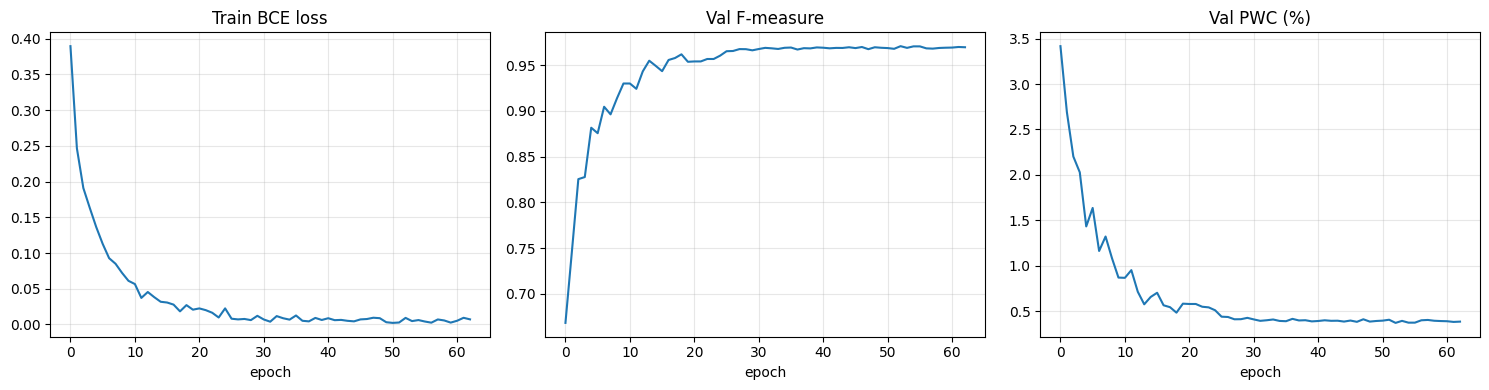

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history["train_loss"]); ax[0].set_title("Train BCE loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["val_f1"]);     ax[1].set_title("Val F-measure");  ax[1].set_xlabel("epoch")
ax[2].plot(history["val_pwc"]);    ax[2].set_title("Val PWC (%)");    ax[2].set_xlabel("epoch")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Quantitative evaluation on held-out frames (per scene + overall)

In [15]:
import pandas as pd
model.eval(); rows = []; overall = SegMetrics()
with torch.no_grad():
    for sd in scene_dirs:
        scene = os.path.basename(sd)
        ds = CDDnetThermal([sd], CONFIG["img_size"], val_frac=0.0, split="val", seed=SEED)
        # use ALL annotated frames of the scene as test when val_frac=0 fallback:
        if len(ds) == 0:
            ds = CDDnetThermal([sd], CONFIG["img_size"], val_frac=0.5, split="val", seed=SEED)
        sm = SegMetrics()
        for x, label, valid, weight in torch.utils.data.DataLoader(ds, batch_size=1):
            x, label, valid = (t.to(device) for t in (x, label, valid))
            out = model(x)
            pred = (torch.sigmoid(out) >= CONFIG["threshold"]).float().cpu().numpy()[0, 0]
            gt = label.cpu().numpy()[0, 0]; vm = valid.cpu().numpy()[0, 0]
            sm.update(pred, gt, vm); overall.update(pred, gt, vm)
        r = sm.results(); r["Scene"] = scene; rows.append(r)
o = overall.results(); o["Scene"] = "OVERALL"; rows.append(o)
df = pd.DataFrame(rows)[["Scene", "Precision", "Recall", "F-measure", "PWC"]]
print(df.to_string(index=False))

[val] 1 frames from 1 scenes
[val] 1 frames from 1 scenes
[val] 1 frames from 1 scenes
[val] 1 frames from 1 scenes
[val] 1 frames from 1 scenes
     Scene  Precision   Recall  F-measure      PWC
  corridor   0.972694 0.962185   0.967411 0.285990
diningRoom   0.969889 0.914691   0.941482 1.289490
  lakeSide   0.000000 0.000000   0.000000 0.000000
   library   0.000000 0.000000   0.000000 0.586001
      park   0.000000 0.000000   0.000000 0.191406
   OVERALL   0.958275 0.894172   0.925115 0.467584


## 16. Qualitative results (input / GT / MSCP prediction)

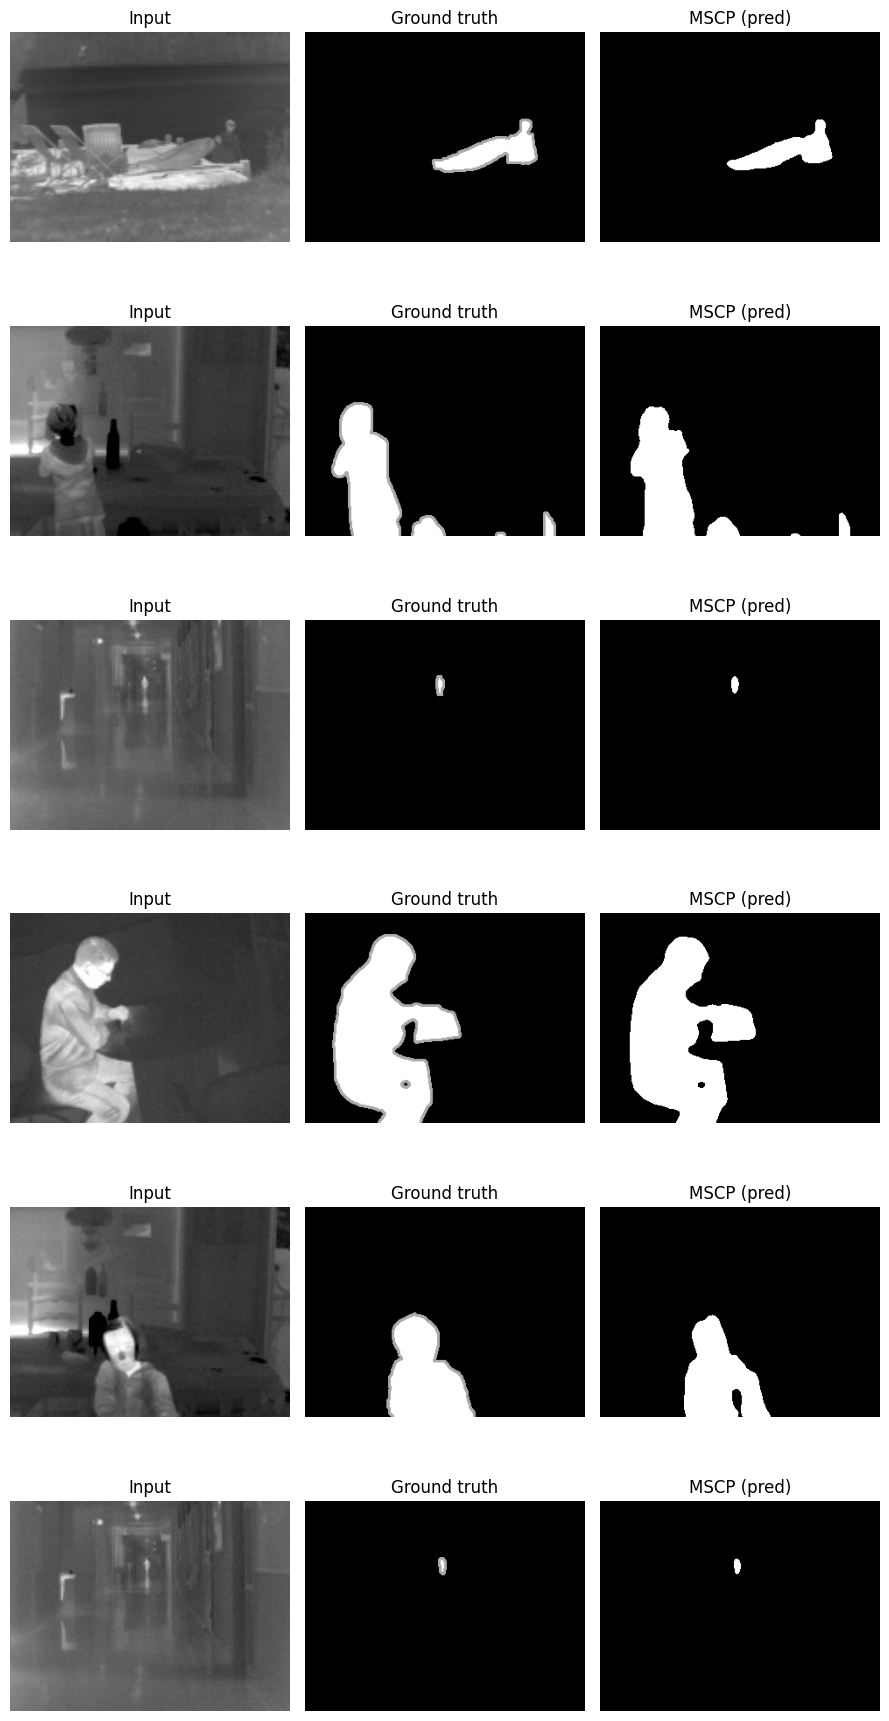

In [16]:
def overlay(mask, base):  # red overlay of predicted mask on the frame
    out = base.copy(); m = mask > 0.5
    out[m] = [0, 0, 255]; return out

model.eval()
samples = val_ds.pairs[:6] if len(val_ds.pairs) >= 6 else val_ds.pairs
fig, axs = plt.subplots(len(samples), 3, figsize=(9, 3 * len(samples)))
if len(samples) == 1: axs = axs[None, :]
for r, (fpath, gtpath, roipath) in enumerate(samples):
    H, W = CONFIG["img_size"]
    frame = cv2.resize(cv2.cvtColor(cv2.imread(fpath), cv2.COLOR_BGR2RGB), (W, H))
    gt = cv2.resize(cv2.imread(gtpath, cv2.IMREAD_GRAYSCALE), (W, H), interpolation=cv2.INTER_NEAREST)
    x = torch.from_numpy(frame.astype(np.float32) / 255.0).permute(2, 0, 1)[None].to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    pred = (prob >= CONFIG["threshold"]).astype(np.uint8)
    axs[r, 0].imshow(frame);        axs[r, 0].set_title("Input");      axs[r, 0].axis("off")
    axs[r, 1].imshow(gt, cmap="gray");  axs[r, 1].set_title("Ground truth"); axs[r, 1].axis("off")
    axs[r, 2].imshow(pred, cmap="gray");axs[r, 2].set_title("MSCP (pred)");  axs[r, 2].axis("off")
plt.tight_layout(); plt.show()

## 17. Save checkpoint & results

In [17]:
os.makedirs("outputs", exist_ok=True)
torch.save({"state_dict": model.state_dict(), "config": CONFIG}, "outputs/mscp_cdnet2014.pth")
df.to_csv("outputs/cdnet2014_thermal_results.csv", index=False)
print("Saved outputs/mscp_cdnet2014.pth and outputs/cdnet2014_thermal_results.csv")

Saved outputs/mscp_cdnet2014.pth and outputs/cdnet2014_thermal_results.csv
